# STAT 207 — Player Position and Market Value

**Portfolio adaptation of a group-submitted course assignment.** I independently completed the Python code, statistical analyses, visualizations, and written interpretations presented here. The original course submission listed group members; this public-facing copy does not replace the original submission.

*University of Illinois Urbana-Champaign · STAT 207*

## 1. Introduction

##### Personal Motivation

Soccer is definitly the most popular sports in the world, and the World Cup is going to be held just few months later. The reason why I choose this dataset is because I am a crazy soccer fans. Because of this, I am willing to choose this fifa dataset having players with there performance and market values in it.

##### Research Question & Contextual Importance

The research question will be "how market value differ across player positions in the FIFA dataset?" One issue that I often come across is that the value of stricker is much higher than that of defenders, and soccer fans often debate whether this statement is ture or not. This often happends because the data of stricker and forwards is more visualized and can be judged by their goals and assists, but for defenders, they rarely score a goal or an assits. But is the argument actually the case in reality? These remain some questions that I need to futher explore, which may provide some insights into how the market value differed of different position or types of players.

## 2. Dataset Discussion

##### Source
This dataset comes from "kaggle", downloaded on Feb 18, 2026, with the link https://www.kaggle.com/datasets/jayjoshi37/fifa-player-performance-and-market-value-analytics?resource=download. I downloaded it as a csv file, named "fifa_player_performance_market_value.csv".

##### Data Collection

This dataset includes player demographics, position, overall rating, potential, match performance metrics (goals, assists, minutes played), contract information, and estimated market value. However, the specific data collection process of this data is unknown, but I guess it may be data obtained from the FIFA official website.

##### Data Set

In [3]:
#Imports here
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()  

In [7]:
df = pd.read_csv("fifa_player_performance_market_value.csv")
df.head(10)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High


In [5]:
df.shape

(2800, 16)

The dataset contains totally 2800 rows and 16 colomns

##### Unit of Observation

I can see from the df.head, that each row in this dataset represents one player with their basic information, for example their age, nationality, club, and position, also their aggregated performance statistics, for example their matches and minutes played, goals, and assists, along with their estimated market value.

##### Variables

As written in part one, the two variables I will focused on is position and market_value_million_eur. Where position is a categorial variable, it shows the position of each player on the field, and market_value_million_eur is the quantitative variable, measured in million euro.

##### Critical Thinking

This dataset has many limitations. The most crucial point is that the players in this dataset are all labeled with numbers, like player_1, player2... So that I don't know which numbers correspond to which actual players. Also, this dataset does not clearly explain how the market value is estimated. 

The most important point is that in terms of player's data, this dataset only shows player's goals, assists, and played time. However, I know that for defenders or goalkeepers, their goal and assist are very limited. Therefore, this data lacks some more comprehensive data such as interceptions, savings, dribblings, and blockings, these are things I want to add if I am the dataset maker.

## 3. Dataset Cleaning

##### Missing Values

In [9]:
df.isna().sum()

player_id                   0
player_name                 0
age                         0
nationality                 0
club                        0
position                    0
overall_rating              0
potential_rating            0
matches_played              0
goals                       0
assists                     0
minutes_played              0
market_value_million_eur    0
contract_years_left         0
injury_prone                0
transfer_risk_level         0
dtype: int64

In [12]:
df['position'].value_counts()

position
ST     329
LW     328
LB     323
GK     317
CB     315
CDM    305
CM     302
RW     295
RB     286
Name: count, dtype: int64

In [14]:
df['market_value_million_eur'].dtype

dtype('float64')

From the code above, I can see that there are no missing values automatically detected by python when using "df.isna().sum()", and I also checked for implicit missing values of the two variables I are interested in which is related with my research question, and I can confirm that the variable "market_value_million_eur" does not contain any hidden string values or formatting issues since they are all stored as a numeric variable, which is a float. Also, I used "value_counts()" in order to identify if there are any unusual values such as “unknown” or empty strings, however, no such values were observed. So that since there are no missing values, nothing will be droped.

##### Uncommon Values

##### Categorical

In [23]:
df['position'].value_counts()

position
ST     329
LW     328
LB     323
GK     317
CB     315
CDM    305
CM     302
RW     295
RB     286
Name: count, dtype: int64

For the categorical data, the position variable contains many detailed positions, such as ST, LW, RW... Even though these positions appears in a kind of equally frequency, but the full set of positions would make the visualization cluttered and hard to intepret, so that I choose to group them into three categories:

Forwards (ST, LW, RW)

Midfielders (CM, CDM)

Defenders (CB, LB, RB, GK)

After grouping them by these three categories, this will simplify the data's interpretation and allow us to get a clearer comparison between each player's position roles.

##### Quantitative

In [17]:
df["market_value_million_eur"].describe()

count    2800.000000
mean       90.565500
std        52.078881
min         0.670000
25%        45.355000
50%        89.170000
75%       136.682500
max       179.960000
Name: market_value_million_eur, dtype: float64

<Axes: >

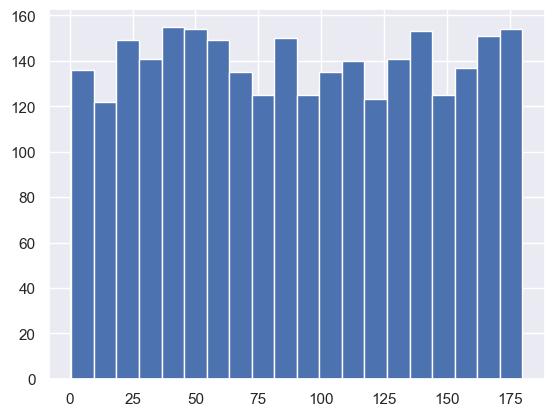

In [22]:
df["market_value_million_eur"].hist(bins=20)

By using the statstics summary and the histogram, I can see that the minimum market value of a player in this dataset is 0.67 million euros, and the maximum is 179.96 million euros. The mean is 90.5655 million euros and the median is 89.17 million euros, which shows that they are very similar with each other, this means that the distribution is relatively symmetrical rather than skewed, and this can also be concluded from the histogram above. Since there are no values smaller than 0 and really outrageous large values, I might think that all the observations are correct, nothing will be dropped.

##### Other Data Cleaning

I did not encounter any additional data cleaning needs throughout the project, so no further data cleaning steps required.

## 4. Summarizing Data

##### Research Question

How market value differ across player positions in the FIFA dataset?

##### Visualization

In [29]:
def three_positions(pos):
    if pos == "ST" or pos == "LW" or pos == "RW":
        return "Forwards"
    elif pos == "CM" or pos == "CDM":
        return "Midfielders"
    elif pos == "CB" or pos == "LB" or pos == "RB" or pos == "GK":
        return "Defenders"
    else:
        return "Other"
    
df["positions_after_grouped"] = df["position"].apply(three_positions)
df.head(10)

,player_id,player_name,age,nationality,club,position,overall_rating,potential_rating,matches_played,goals,assists,minutes_played,market_value_million_eur,contract_years_left,injury_prone,transfer_risk_level,positions after grouped,positions_after_grouped
0,1,Player_1,23,Germany,Liverpool,ST,65,87,8,6,14,2976,122.51,3,No,Low,Forwards,Forwards
1,2,Player_2,36,England,FC Barcelona,ST,90,76,19,3,18,2609,88.47,5,No,High,Forwards,Forwards
2,3,Player_3,31,France,Juventus,RB,75,91,34,12,15,1158,20.24,3,No,Medium,Defenders,Defenders
3,4,Player_4,27,Portugal,Manchester City,LW,90,86,35,18,13,145,164.29,0,Yes,Medium,Forwards,Forwards
4,5,Player_5,24,Brazil,Liverpool,CDM,84,96,41,6,6,2226,121.34,4,No,Low,Midfielders,Midfielders
5,6,Player_6,37,Argentina,Manchester City,CM,92,91,35,9,7,263,98.51,5,Yes,Low,Midfielders,Midfielders
6,7,Player_7,23,Netherlands,Liverpool,RB,72,66,53,24,6,4299,67.69,1,No,Low,Defenders,Defenders
7,8,Player_8,35,Spain,Bayern Munich,LW,69,97,8,34,17,3101,24.71,0,No,Low,Forwards,Forwards
8,9,Player_9,39,Brazil,FC Barcelona,GK,83,90,21,24,23,2106,127.50,3,Yes,High,Defenders,Defenders
9,10,Player_10,27,England,Liverpool,LB,69,92,0,28,5,3080,146.55,1,No,High,Defenders,Defenders


In [28]:
df["positions_after_grouped"].value_counts()

positions_after_grouped
Defenders      1241
Forwards        952
Midfielders     607
Name: count, dtype: int64

Text(0.5, 1.0, 'Boxplot of Market Values by positions')

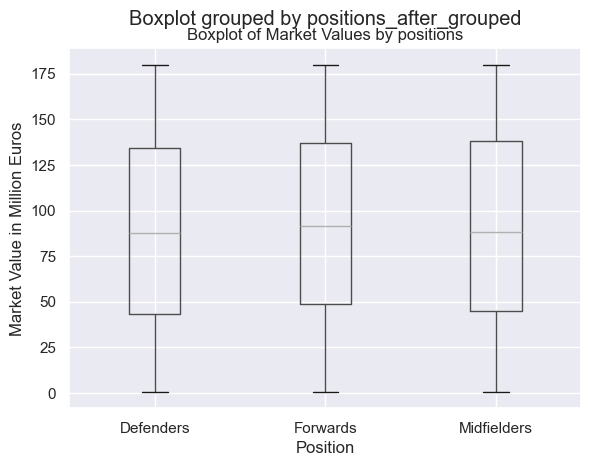

In [33]:
df.boxplot(column="market_value_million_eur", by="positions_after_grouped")
plt.xlabel("Position")
plt.ylabel("Market Value in Million Euros")
plt.title("Boxplot of Market Values by positions")

##### Set of Summary Statistics

In [35]:
df.groupby("positions_after_grouped")["market_value_million_eur"].mean()

positions_after_grouped
Defenders      89.400113
Forwards       92.447731
Midfielders    89.996079
Name: market_value_million_eur, dtype: float64

In [36]:
df.groupby("positions_after_grouped")["market_value_million_eur"].median()

positions_after_grouped
Defenders      87.89
Forwards       91.57
Midfielders    88.05
Name: market_value_million_eur, dtype: float64

I calculated the mean and the median or the market values of Forwards, Midfielders, and Defenders, and I can see that they are relatively similar, which is a relatively symmetric distributions within these three categories.

##### Descriptions

The boxplot shows that the distributions of market value are very similar across the three position categories, and the medians for all groups are within a very narrow range. Also, from the boxplot, I can see that the IQR is also really similar, which suggests that the spread of the market values of each position group is consistent, with the maximum values for all groups close to 180 million euros, and there are no outliers. The further numerical data also represents that the three categories as a very similar mean and median compared with each other. So that the distributions across the three categories appears very symmetric.

##### Result Discussion

Based on both the boxplot and the summary statistics, I can concludes that market value does not differ substantially across player's positions in this dataset, sicne there is only some minor differences in values, the overall distributions are highly similar with each other. So that within this dataset, position does not appear to be associated with the market values.

## 5. Conclusion

##### Summarization

This is a FIFA dataset which includes player demographics, position, overall rating, potential, match performance metrics (goals, assists, minutes played), contract information, and estimated market value. After the examining the data, I found that there are no missing values and no uncommon values. I further grouped the detailed player's positons to three categories, which are Fowards, Midfielders, and Defenders, in order to make the analysis more explicit. My research question is "How market value differ across player positions in the FIFA dataset?" Based on the boxplot visualization and the numerical values, I concludes that the distributions are highly similar across the three groups, so that within this dataset, position does not appear to be associated with the market values.

##### Limitations

What challenges did I face in my data analysis?

* During the data analysis process, one of the main challenges is that the "position" variable contains a lot of exact positions, such as ST, LW, CM, etc. If I directly compare each specific position, the chart would be very complex and difficult to show the differences between different groups. So that I need to combine the original positions into three larger categories, which are Forwards, Midfielders, and Defenders in order to get clearer visualization.

What limitations did I face in my analysis, results, or interpretations?

* One major limitation is that the dataset origin and the calculation method of market value are not clear, so I don't know whether this can truly reflect the actual situation of the football market. Therefore, my analysis results can only be limited to the current dataset and are just descriptive conclusions. Also, I only analyzed the relationship between player positions and their market values, but did not considered other factors that might affect the value, such as the overall rating, age, and their performance in matches, etc. Because in reality, a player's value is usually determined by multiple factors.


##### Future Work

Future work may be associated with other variables related with market value, or example the relationship between the overall rating and the market value, or between the number of goals and the market values, etc. These further analysis will give us more comprehensive understanding towards factors that associated with player's market values.